In [69]:
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from typing import TypedDict, Literal
from typing_extensions import Annotated
# reducer
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
import os
from langchain_core.messages import SystemMessage, HumanMessage, BaseMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()
project = os.getenv('GOOGLE_CLOUD_PROJECT')


# model
llm = ChatGoogleGenerativeAI(
    model = "gemini-2.5-flash-lite",
    vertexai = True,
    project = project
)

In [70]:
from langgraph.graph import MessagesState

In [71]:
def node_1(state: MessagesState):
    role = [SystemMessage(content="You are expert in the field of Software")]
    
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

def node_2(state: MessagesState):
    role = [SystemMessage(content="You are helpful assistant")]
    response = llm.invoke(role + state["messages"])
    return {"messages": response}

In [72]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)


In [73]:
# sequence 

graph.set_entry_point("expert")
graph.add_edge("expert", "assistant")
graph.set_finish_point("assistant")

In [74]:
state_graph = graph.compile()

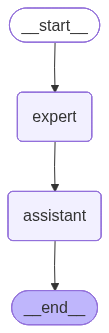

In [75]:
state_graph

In [76]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

In [77]:
for message in response['messages']:
    print(message.content)

What is class ?
In the realm of software development, particularly in **object-oriented programming (OOP)**, a **class** is a fundamental concept. You can think of it as a **blueprint** or a **template** for creating objects.

Here's a breakdown of what a class is and its key characteristics:

**Core Idea: A Blueprint for Objects**

Imagine you want to create multiple cars. Instead of describing each car from scratch, you'd first define what a "car" generally is. This definition would include things like:

*   **What properties does a car have?** (e.g., color, brand, model, number of doors, current speed)
*   **What actions can a car perform?** (e.g., start engine, accelerate, brake, turn)

This general definition of a "car" is analogous to a **class**.

**When you use this blueprint to create an actual car (e.g., "my red Toyota Camry"), that specific car is called an object (or an instance of the class).**

**Key Components of a Class:**

1.  **Attributes (or Properties, Data Members,

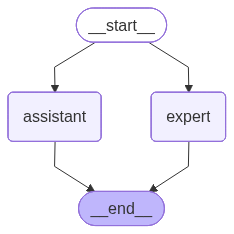

In [78]:
graph = StateGraph(MessagesState)

graph.add_node("expert", node_1)
graph.add_node("assistant", node_2)
graph.set_entry_point("expert")
graph.set_entry_point("assistant")
graph.set_finish_point("assistant")
graph.set_finish_point("expert")
state_graph = graph.compile()
state_graph

In [79]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What is class ?")]})

for message in response['messages']:
    print(message.content)

What is class ?
In object-oriented programming (OOP), a **class** is a blueprint or a template for creating objects. It defines the properties (attributes or data members) and behaviors (methods or functions) that objects of that class will have.

Think of it like a blueprint for a house:

*   **The Blueprint (Class):** The blueprint specifies what a house will look like. It defines the number of rooms, the dimensions of each room, where the doors and windows go, what materials will be used, etc. The blueprint itself is not a house; it's just the design.

*   **The Houses (Objects):** Based on that blueprint, you can build multiple actual houses. Each house is an **object** created from the blueprint. Each house will have the same structure (rooms, doors, windows) defined by the blueprint, but they can have different specific characteristics (e.g., different paint colors, different furniture inside).

**Key Concepts Related to Classes:**

1.  **Objects (Instances):** An object is a con

In [80]:
# Sample Structure used 

class ExtendedMessagesState(MessagesState):
    expert_one: str = "Software"
    expert_two: str = "Design"

In [81]:
# Simulate chat bot

def ask_question(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}
chat_graph = StateGraph(MessagesState)
chat_graph.add_node("chat", ask_question)
chat_graph.set_entry_point("chat")
chat_graph.set_finish_point("chat")
chat_state_graph = chat_graph.compile()


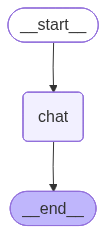

In [82]:
chat_state_graph

In [83]:
# in my state i have list of lenght 1
response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
})

len(response['messages'])

2

In [84]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The capital of France is **Paris**.


In [85]:
response = state_graph.invoke(
    {"messages": [HumanMessage(content="What are good spots in the city")]}
)
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

To give you the best recommendations, I need a little more information! "The city" is a very broad term.

**Please tell me:**

1.  **Which city are you interested in?** (e.g., New York City, London, Tokyo, Paris, your local city, etc.)
2.  **What kind of "spots" are you looking for?** Are you interested in:
    *   **Tourist Attractions?** (Famous landmarks, museums, historical sites)
    *   **Food & Drink?** (Restaurants, cafes, bars, specific cuisines)
    *   **Entertainment?** (Live music venues, theaters, comedy clubs, movie theaters)
    *   **Nature & Outdoors?** (Parks, gardens, waterfronts, hiking trails)
    *   **Shopping?** (Boutiques, markets, malls)
    *   **Art & Culture?** (Galleries, street art, cultural centers)
    *   **Relaxation?** (Spas, quiet cafes, scenic viewpoints)
    *   **Family-friendly activities?**
    *   **Nightlife?**
    *   **Hidden Gems?** (Less touristy, local fav

In [86]:
config = {"configurable": {"thread_id": "3"}}

response = chat_state_graph.invoke({
    "messages": [HumanMessage("What is captial of france?")]
}, config=config
)


In [87]:
len(response['messages'])

2

In [88]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

The capital of France is **Paris**.


In [89]:
response = chat_state_graph.invoke(
    {
        "messages": [HumanMessage(content="What are good spots in this city")]
    },
    config=config
)


In [90]:
len(response['messages'])

2

In [91]:
response['messages']

[HumanMessage(content='What are good spots in this city', additional_kwargs={}, response_metadata={}, id='c9cef638-c804-468e-9840-fd2d091598e5'),
 AIMessage(content="To give you the best recommendations, I need a little more information! **What city are you referring to?**\n\nOnce you tell me the city, I can help you find great spots for:\n\n**General Interests:**\n\n*   **Sightseeing/Landmarks:** Iconic buildings, historical sites, famous monuments.\n*   **Parks & Nature:** Green spaces, gardens, hiking trails, scenic views.\n*   **Museums & Galleries:** Art, history, science, niche collections.\n*   **Entertainment:** Live music venues, theaters, comedy clubs, sports arenas.\n*   **Shopping:** Boutiques, malls, local markets, unique shops.\n*   **Food & Drink:** Restaurants (various cuisines, price points), cafes, bars, breweries, wineries.\n*   **Nightlife:** Clubs, bars with good atmosphere, rooftop bars.\n*   **Family-Friendly Activities:** Zoos, aquariums, kid-focused museums, pl

In [92]:
response['messages'][-1].pretty_print()

================================== Ai Message ==================================

To give you the best recommendations, I need a little more information! **What city are you referring to?**

Once you tell me the city, I can help you find great spots for:

**General Interests:**

*   **Sightseeing/Landmarks:** Iconic buildings, historical sites, famous monuments.
*   **Parks & Nature:** Green spaces, gardens, hiking trails, scenic views.
*   **Museums & Galleries:** Art, history, science, niche collections.
*   **Entertainment:** Live music venues, theaters, comedy clubs, sports arenas.
*   **Shopping:** Boutiques, malls, local markets, unique shops.
*   **Food & Drink:** Restaurants (various cuisines, price points), cafes, bars, breweries, wineries.
*   **Nightlife:** Clubs, bars with good atmosphere, rooftop bars.
*   **Family-Friendly Activities:** Zoos, aquariums, kid-focused museums, playgrounds.
*   **Unique Experiences:** Anything that makes the city special or unusual.

**To hel

In [94]:
def response_from_llm(state: MessagesState):
    return {
        "messages": llm.invoke(state["messages"])
    }

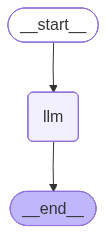

In [95]:
state_learning_graph = StateGraph(MessagesState)
state_learning_graph.add_node("llm", response_from_llm)

state_learning_graph.set_entry_point("llm")
state_learning_graph.set_finish_point("llm")

compiled_state_learning_graph = state_learning_graph.compile()
compiled_state_learning_graph

In [100]:
config = {"configurable": {"thread_id": "1"}}

input_message = HumanMessage(content="Hi this is Ram speaking")
output = compiled_state_learning_graph.invoke(
    {
        "messages": [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

Hi Ram, nice to meet you! How can I help you today?


In [102]:
previous_message = output['messages']
previous_message

[HumanMessage(content='Hi this is Ram speaking', additional_kwargs={}, response_metadata={}, id='fc39a217-a558-46c9-963b-0ccfd796cc0a'),
 AIMessage(content='Hi Ram, nice to meet you! How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d8a03-307d-7260-82f7-1c3d61d22064-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 5, 'output_tokens': 15, 'total_tokens': 20, 'input_token_details': {'cache_read': 0}})]

In [ ]:
input_message = HumanMessage(content="What is my name ?")
output = compiled_state_learning_graph.invoke(
    {
        # There is a native way of doing this  => checkpoint, memory and thread
        "messages": previous_message + [input_message]
    }, 
    config
)
output['messages'][-1].pretty_print()

================================== Ai Message ==================================

You just told me your name is Ram!
